# Análisis Exploratorio de Datos - Dataset de Vinos

Este notebook realiza un proceso de Data Wrangling y EDA sobre datasets de vinos rojos y blancos utilizando Python.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vino_rojo = pd.read_csv("winequality-red.csv", sep=";")
vino_blanco = pd.read_csv("winequality-white.csv", sep=";")

# Crear columna para identificar tipo de vino

vino_rojo["tipo_vino"] = "rojo"
vino_blanco["tipo_vino"] = "blanco"

# Unir datasets

df = pd.concat([vino_rojo, vino_blanco])

In [3]:
# mostrar primeras filas
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo_vino
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,rojo
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,rojo
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,rojo
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,rojo
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,rojo


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  tipo_vino             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 710.6 KB


In [ ]:
# estadística generales
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
#verificacion de valores nulos
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
tipo_vino               0
dtype: int64

In [7]:
# Verificación de duplicados

df.duplicated().sum()

np.int64(1177)

In [8]:
# Eliminación de registros duplicados

df = df.drop_duplicates()

df.shape

(5320, 13)

## Análisis Exploratorio de Datos (EDA)

A continuación se realizan diferentes visualizaciones para analizar:
- Tipo de vino
- Calidad
- Nivel de alcohol
- pH

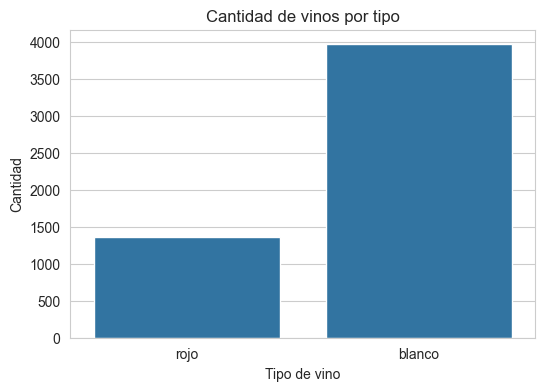

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="tipo_vino")

plt.title("Cantidad de vinos por tipo")

plt.xlabel("Tipo de vino")
plt.ylabel("Cantidad")

plt.show()

### Conclusión

Se observa que el dataset contiene una mayor cantidad de vinos blancos en comparación con los vinos rojos.

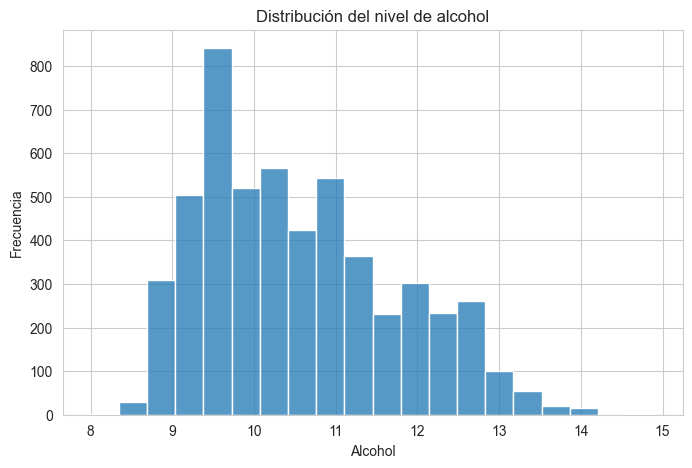

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["alcohol"], bins=20)

plt.title("Distribución del nivel de alcohol")

plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")

plt.show()

### Conclusión

La mayoría de vinos presentan niveles de alcohol intermedios. Existen pocos vinos con valores extremadamente altos o bajos.

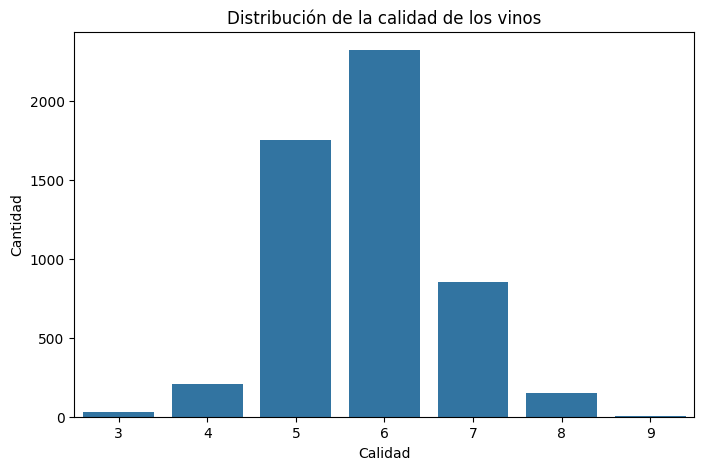

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality")

plt.title("Distribución de la calidad de los vinos")

plt.xlabel("Calidad")
plt.ylabel("Cantidad")

plt.show()

### Conclusión

La mayoría de vinos tienen una calidad media, especialmente entre los valores 5 y 6.

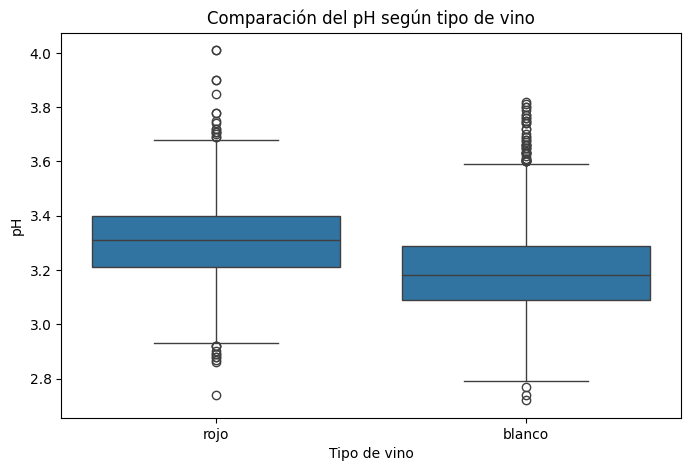

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="tipo_vino", y="pH")

plt.title("Comparación del pH según tipo de vino")

plt.xlabel("Tipo de vino")
plt.ylabel("pH")

plt.show()

### Conclusión

Se observan diferencias en los niveles de pH entre vinos rojos y blancos.

In [15]:
print("""
CONCLUSIONES GENERALES

1. Se realizó un proceso de limpieza de datos sobre los datasets de vinos.
2. No se encontraron valores nulos en las variables analizadas.
3. Se identificaron y eliminaron registros duplicados.
4. La mayoría de vinos presentan calidad media.
5. Los niveles de alcohol se concentran en valores intermedios.
6. Existen diferencias de pH entre vinos blancos y rojos.
""")


CONCLUSIONES GENERALES

1. Se realizó un proceso de limpieza de datos sobre los datasets de vinos.
2. No se encontraron valores nulos en las variables analizadas.
3. Se identificaron y eliminaron registros duplicados.
4. La mayoría de vinos presentan calidad media.
5. Los niveles de alcohol se concentran en valores intermedios.
6. Existen diferencias de pH entre vinos blancos y rojos.

